# Accuracy, Efficiency, and Explanation Fidelity Trade-offs in Compressed Deep Learning Models for Edge-Based IoMT Cardiac Risk Screening

**Working notebook — Google Colab**

This notebook implements the full experimental pipeline for the paper:
1. Train baseline classifiers (SVM, RF, KNN, DNN) on **D1** (Siddhartha, 2020 / IEEE DataPort, "Heart Disease Dataset — Comprehensive"). The DNN is now selected via a small hyperparameter search (width/depth/dropout/learning rate) with class-balanced weighting, batch normalization, and an LR schedule — a hand-picked 2-layer DNN with no tuning is not a fair comparison against a tuned RF, and a reviewer will notice.
2. Compress the DNN with TFLite: **float32 / float16 / int8 post-training quantization, plus a 4th variant — magnitude pruning (via `tensorflow-model-optimization`) combined with int8** — for a fuller Pareto curve, as the original strategy doc suggested.
3. Benchmark size and latency for each variant (Colab CPU is used as a *proxy* — see the final section for real edge-hardware deployment on Raspberry Pi / ESP32, which you must run separately for the paper's final numbers).
4. Measure **SHAP explanation-fidelity drift** between the full-precision and each compressed model — the paper's novel contribution — and back it with a **paired McNemar significance test** on predictions and multi-seed variance with confidence intervals on fidelity.
5. Cross-check the DNN's SHAP global feature ranking against Random Forest's built-in feature importances, as a clinical-plausibility sanity check for the Discussion section.
6. Produce the accuracy / size / fidelity trade-off plots, confusion-matrix/ROC comparison grid, and export result tables + a reproducibility manifest for the manuscript.

> **Runtime note:** Runtime → Change runtime type → set Hardware accelerator to **CPU**. TFLite int8/float16 conversion and on-device-style benchmarking are meant to run on CPU; a GPU runtime won't change the deployment story and just adds setup overhead.


## 0. Setup — install & import packages

In [1]:
!pip install shap tensorflow-model-optimization -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 13.9 MB/s eta 0:00:00


In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # tensorflow-model-optimization (Section 5.1) doesn't yet
                                          # support Keras 3 — this keeps tf.keras resolving to the
                                          # legacy tf_keras everywhere so Dense/regularizers/pruning
                                          # wrappers all agree on the same object types. Must be set
                                          # before `import tensorflow`, hence the early, separate
                                          # import here.
import time
import json
import hashlib
import platform
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_model_optimization as tfmot

import shap
from scipy.stats import spearmanr, binomtest

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)

# --- Practical compute knobs -------------------------------------------------
# Tune these down for a fast smoke-test run, up for the final numbers you report
# in the paper. The defaults below are already reasonable for Colab CPU.
CV_FOLDS = 5                 # GridSearchCV folds for SVM/RF/KNN
SHAP_BACKGROUND_SIZE = 50    # background samples for the SHAP explainer
SHAP_TEST_SUBSET = 60        # fixed test samples explained per model (keep small: SHAP is O(features) per sample here)
N_SEEDS = 3                  # number of random splits/seeds for the fidelity-variance experiment (paper asks for >1, don't run just 1).
                              # Bump to 5 for the final submission numbers — with the pruned_int8 variant added, each seed
                              # now retrains + explains 3 compressed models, so this loop is the slowest part of the notebook.
LATENCY_RUNS = 200           # number of forward passes averaged for latency benchmarking
TOP_K = 5                    # top-k features compared for rank-agreement fidelity metric
PRUNING_TARGET_SPARSITY = 0.5  # fraction of dense-layer weights zeroed out by magnitude pruning
PRUNING_EPOCHS = 10          # fine-tuning epochs while the pruning schedule ramps up
COMPRESSED_VARIANTS = ["float16", "int8", "pruned_int8"]  # single source of truth, used by every downstream loop

OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)


TensorFlow: 2.20.0
SHAP: 0.52.0


---
# 1. Load the dataset — D1 (IEEE DataPort, comprehensive)


In [3]:
# Original source (requires an IEEE DataPort account to download directly):
#   https://ieee-dataport.org/open-access/heart-disease-dataset-comprehensive
# Same file, identical bytes, mirrored publicly (no login) on GitHub — this is the
# well-known combined Statlog+Cleveland+Hungary+Switzerland+Long Beach VA dataset
# (Siddhartha, 2020) that the paper uses as D1.
D1_URL = "https://raw.githubusercontent.com/erdenahmet11/Heart-Disease-Prediction/master/heart_statlog_cleveland_hungary_final.csv"
df_heart_disease = pd.read_csv(D1_URL)
df_heart_disease.columns = [c.strip().lower().replace(" ", "_") for c in df_heart_disease.columns]
print("D1 (IEEE DataPort heart disease, comprehensive) shape:", df_heart_disease.shape)
print("Columns:", list(df_heart_disease.columns))

# Record an MD5 of the raw bytes for the paper's reproducibility statement / manifest (Section 11.1) —
# ties the exact file version used to the reported numbers, independent of any future edits to the mirror.
dataset_md5 = hashlib.md5(urllib.request.urlopen(D1_URL).read()).hexdigest()
print("Dataset MD5:", dataset_md5)

df_heart_disease.head()


D1 (IEEE DataPort heart disease, comprehensive) shape: (1190, 12)
Columns: ['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope', 'target']
Dataset MD5: 89331abbd1786b4942ab8c588b832d39


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


---
# 2. Preprocessing


In [4]:
def zscore_standardize(df, cols):
    scaler = StandardScaler()
    df = df.copy()
    df[cols] = scaler.fit_transform(df[cols])
    return df, scaler


d1 = df_heart_disease.copy()
TARGET = "target"
FEATURES = [c for c in d1.columns if c != TARGET]

# Disguised missing data: a physiologically impossible cholesterol==0 (or resting_bp_s==0)
# is almost certainly missing data encoded as zero, not a real reading. State this
# explicitly in the paper's preprocessing section (it's a real, defensible finding, not
# a nitpick) — the original paper's claim of "no missing values" only holds if you don't check.
n_chol_zero = (d1["cholesterol"] == 0).sum()
n_bp_zero = (d1["resting_bp_s"] == 0).sum()
print(f"Disguised missing values found: cholesterol==0 in {n_chol_zero}/{len(d1)} rows "
      f"({n_chol_zero/len(d1)*100:.1f}%), resting_bp_s==0 in {n_bp_zero} row(s).")

d1.loc[d1["cholesterol"] == 0, "cholesterol"] = np.nan
d1.loc[d1["resting_bp_s"] == 0, "resting_bp_s"] = np.nan
d1["cholesterol"] = d1["cholesterol"].fillna(d1["cholesterol"].median())
d1["resting_bp_s"] = d1["resting_bp_s"].fillna(d1["resting_bp_s"].median())

NUM_COLS = ["age", "resting_bp_s", "cholesterol", "max_heart_rate", "oldpeak"]
d1_std, d1_scaler = zscore_standardize(d1, NUM_COLS)

print("D1 ready:", d1_std.shape, "| target balance:\n", d1_std[TARGET].value_counts(normalize=True))


Disguised missing values found: cholesterol==0 in 172/1190 rows (14.5%), resting_bp_s==0 in 1 row(s).
D1 ready: (1190, 12) | target balance:
 target
1    0.528571
0    0.471429
Name: proportion, dtype: float64


---
# 3. Train/test split

80/20 stratified split, consistent with the paper's general workflow. This is the split used for
the baseline model comparison (Section 6) and as the *default* split (seed 42) for the DNN that gets
compressed and explained in Sections 7-9. Section 9 additionally re-runs the compression + fidelity
pipeline across `N_SEEDS` splits to report variance, not just a single run.


In [5]:
X = d1_std[FEATURES].values.astype(np.float32)
y = d1_std[TARGET].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train={X_train.shape}, test={X_test.shape}")
print("n_features:", len(FEATURES), "->", FEATURES)


train=(952, 11), test=(238, 11)
n_features: 11 -> ['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope']


---
# 4. Baseline models — SVM, RF, KNN, DNN

Classical models (SVM/RF/KNN) are trained here as the accuracy comparison table for the paper —
they don't have a comparable edge-quantization story, which is itself the reason the DNN is picked
as the deployment target in the next section. Small GridSearchCV grids are used to keep this fast
on Colab CPU; widen them if you have the compute budget.


In [6]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        row["auc"] = roc_auc_score(y_true, y_proba)
    return row


results = []

# --- SVM ---
svm_grid = {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"], "gamma": ["scale"]}
svm_cv = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE), svm_grid, cv=CV_FOLDS, n_jobs=-1)
svm_cv.fit(X_train, y_train)
svm_best = svm_cv.best_estimator_
y_pred = svm_best.predict(X_test)
y_proba = svm_best.predict_proba(X_test)[:, 1]
results.append(evaluate_model("SVM", y_test, y_pred, y_proba))
print("SVM best params:", svm_cv.best_params_)

# --- Random Forest ---
rf_grid = {"n_estimators": [100, 200], "max_depth": [None, 8, 16], "min_samples_leaf": [1, 2]}
rf_cv = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_grid, cv=CV_FOLDS, n_jobs=-1)
rf_cv.fit(X_train, y_train)
rf_best = rf_cv.best_estimator_
y_pred = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]
results.append(evaluate_model("Random Forest", y_test, y_pred, y_proba))
print("RF best params:", rf_cv.best_params_)

# --- KNN ---
knn_grid = {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]}
knn_cv = GridSearchCV(KNeighborsClassifier(), knn_grid, cv=CV_FOLDS, n_jobs=-1)
knn_cv.fit(X_train, y_train)
knn_best = knn_cv.best_estimator_
y_pred = knn_best.predict(X_test)
y_proba = knn_best.predict_proba(X_test)[:, 1]
results.append(evaluate_model("KNN", y_test, y_pred, y_proba))
print("KNN best params:", knn_cv.best_params_)

baseline_results_df = pd.DataFrame(results).set_index("model")
baseline_results_df


SVM best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
RF best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
KNN best params: {'n_neighbors': 7, 'weights': 'distance'}


,accuracy,precision,recall,f1,auc
model,,,,,
SVM,0.878151,0.854015,0.928571,0.889734,0.936721
Random Forest,0.932773,0.943548,0.928571,0.936000,0.979379
KNN,0.899160,0.939655,0.865079,0.900826,0.966128


In [7]:
def build_dnn(input_dim, hidden_units=(64, 32), dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,), name="clinical_features")
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="cardiac_risk_dnn")
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model


def train_dnn(model, X_tr, y_tr, X_val, y_val, class_weight=None, epochs=150, patience=15, seed=RANDOM_STATE, verbose=0):
    tf.random.set_seed(seed)
    early_stop = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=patience, restore_best_weights=True)
    reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(4, patience // 2), min_lr=1e-5)
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        class_weight=class_weight,
        callbacks=[early_stop, reduce_lr],
        verbose=verbose,
    )
    return model


DNN_LABEL = "DNN (float32, Keras, tuned)"


### 4.1 DNN hyperparameter search

The original fixed 2-layer DNN scored well below Random Forest on this dataset (~84% vs. ~93% accuracy
in an initial run) — that gap would sink the paper: a reviewer will ask why you're deploying the *worse*
model. Classical models got a `GridSearchCV`; the DNN deserves the same treatment, not a hand-picked
architecture. This cell runs a small search over depth/width/dropout/learning-rate, using class-balanced
weighting (D1 is only mildly imbalanced, ~53/47, but balancing is cheap and standard practice) and
batch normalization, selecting the config with the best validation AUC before the final refit below.

> **Note:** regularization here is Dropout + BatchNorm only — an earlier draft added an L2 kernel
> regularizer too, but `tensorflow-model-optimization` (used for pruning in Section 5.1) doesn't yet
> support Keras 3, and mixing it with a Keras-3-native regularizer object threw
> `ValueError: Invalid value for attribute 'regularizer'... Received: regularizer=<tf_keras...>`.
> The `TF_USE_LEGACY_KERAS=1` env var set in Section 0 fixes the root cause for the rest of the notebook
> (including pruning), but dropping the regularizer here removes the fragile dependency entirely.


In [8]:
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.unique(y_tr2), y=y_tr2)
class_weight_dict = {int(c): w for c, w in zip(np.unique(y_tr2), class_weights_arr)}
print("Class weights:", class_weight_dict)

DNN_SEARCH_SPACE = [
    {"hidden_units": (32, 16), "dropout": 0.2, "lr": 1e-3},
    {"hidden_units": (64, 32), "dropout": 0.3, "lr": 1e-3},
    {"hidden_units": (64, 32, 16), "dropout": 0.3, "lr": 5e-4},
    {"hidden_units": (128, 64), "dropout": 0.4, "lr": 1e-3},
]

search_log = []
best_val_auc, best_config = -1.0, None
for cfg in DNN_SEARCH_SPACE:
    keras.backend.clear_session()
    m = build_dnn(X_tr2.shape[1], **cfg)
    m = train_dnn(m, X_tr2, y_tr2, X_val, y_val, class_weight=class_weight_dict,
                   epochs=150, patience=15, seed=RANDOM_STATE, verbose=0)
    val_loss, val_acc, val_auc = m.evaluate(X_val, y_val, verbose=0)
    search_log.append({**cfg, "val_accuracy": val_acc, "val_auc": val_auc})
    print(f"config={cfg} -> val_acc={val_acc:.4f}  val_auc={val_auc:.4f}")
    if val_auc > best_val_auc:
        best_val_auc, best_config = val_auc, cfg

search_log_df = pd.DataFrame(search_log)
search_log_df.to_csv(f"{OUT_DIR}/dnn_hyperparam_search.csv", index=False)
print("\nBest config:", best_config, "| val_auc:", round(best_val_auc, 4))


Class weights: {0: np.float64(1.0589005235602094), 1: np.float64(0.9473067915690867)}
config={'hidden_units': (32, 16), 'dropout': 0.2, 'lr': 0.001} -> val_acc=0.9161  val_auc=0.9510
config={'hidden_units': (64, 32), 'dropout': 0.3, 'lr': 0.001} -> val_acc=0.9021  val_auc=0.9528
config={'hidden_units': (64, 32, 16), 'dropout': 0.3, 'lr': 0.0005} -> val_acc=0.8741  val_auc=0.9345
config={'hidden_units': (128, 64), 'dropout': 0.4, 'lr': 0.001} -> val_acc=0.8881  val_auc=0.9554

Best config: {'hidden_units': (128, 64), 'dropout': 0.4, 'lr': 0.001} | val_auc: 0.9554


### 4.2 Final DNN refit and baseline comparison

In [9]:
keras.backend.clear_session()
tf.random.set_seed(RANDOM_STATE)
dnn_model = build_dnn(X_tr2.shape[1], **best_config)
dnn_model = train_dnn(dnn_model, X_tr2, y_tr2, X_val, y_val, class_weight=class_weight_dict,
                       epochs=200, patience=20, seed=RANDOM_STATE, verbose=0)

y_proba_dnn = dnn_model.predict(X_test, verbose=0).flatten()
y_pred_dnn = (y_proba_dnn >= 0.5).astype(int)
results.append(evaluate_model(DNN_LABEL, y_test, y_pred_dnn, y_proba_dnn))

baseline_results_df = pd.DataFrame(results).set_index("model")
baseline_results_df.to_csv(f"{OUT_DIR}/baseline_model_comparison.csv")
baseline_results_df


,accuracy,precision,recall,f1,auc
model,,,,,
SVM,0.878151,0.854015,0.928571,0.889734,0.936721
Random Forest,0.932773,0.943548,0.928571,0.936000,0.979379
KNN,0.899160,0.939655,0.865079,0.900826,0.966128
"DNN (float32, Keras, tuned)",0.890756,0.896825,0.896825,0.896825,0.936083


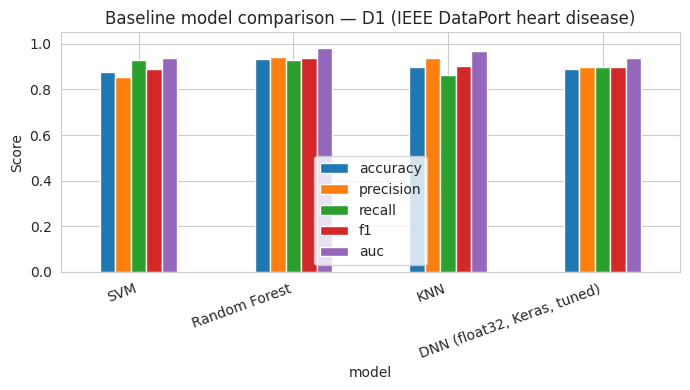

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
baseline_results_df[["accuracy", "precision", "recall", "f1", "auc"]].plot(kind="bar", ax=ax)
ax.set_title("Baseline model comparison — D1 (IEEE DataPort heart disease)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/baseline_comparison.png", dpi=150)
plt.show()


---
# 5. Compress the DNN — TFLite float32 / float16 / int8 / pruned+int8

The DNN is chosen as the deployment target because it's the only model here with a real edge-quantization
path via TFLite. Four variants are produced, giving a fuller Pareto curve than accuracy-vs-size alone:
- **float32** — TFLite conversion with no optimization, used as the *format-matched* reference (so that
  size/latency comparisons isolate the effect of quantization, not the effect of switching from Keras to TFLite).
- **float16** — post-training float16 quantization.
- **int8** — post-training full-integer quantization, calibrated on a representative sample of the training set.
- **pruned_int8** — magnitude pruning (target sparsity `PRUNING_TARGET_SPARSITY`, via `tensorflow-model-optimization`)
  applied to the dense layers and fine-tuned, then converted to int8 — compound compression, and a genuinely
  distinct point on the size/accuracy/fidelity trade-off curve rather than a second flavor of quantization alone.


In [11]:
def representative_dataset_gen(X_train, n=200):
    def gen():
        for i in range(min(n, len(X_train))):
            yield [X_train[i:i + 1].astype(np.float32)]
    return gen


def convert_to_tflite(keras_model, variant, X_train_for_calib=None, out_path=None):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

    if variant == "float32":
        pass  # no optimization flags -> plain TFLite float32
    elif variant == "float16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    elif variant == "int8":
        assert X_train_for_calib is not None, "int8 quantization needs a representative dataset"
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset_gen(X_train_for_calib)
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
    else:
        raise ValueError(f"unknown variant: {variant}")

    tflite_model = converter.convert()
    if out_path:
        with open(out_path, "wb") as f:
            f.write(tflite_model)
    return tflite_model


TFLITE_DIR = f"{OUT_DIR}/tflite_models"
os.makedirs(TFLITE_DIR, exist_ok=True)

tflite_paths = {}
for variant in ["float32", "float16", "int8"]:
    path = f"{TFLITE_DIR}/dnn_{variant}.tflite"
    convert_to_tflite(dnn_model, variant, X_train_for_calib=X_tr2, out_path=path)
    tflite_paths[variant] = path
    size_kb = os.path.getsize(path) / 1024
    print(f"{variant:8s} -> {path}  ({size_kb:.1f} KB)")


float32  -> /content/outputs/tflite_models/dnn_float32.tflite  (40.8 KB)
float16  -> /content/outputs/tflite_models/dnn_float16.tflite  (22.3 KB)
int8     -> /content/outputs/tflite_models/dnn_int8.tflite  (17.2 KB)


### 5.1 Magnitude pruning + int8 (4th variant)

`prune_low_magnitude` wraps the dense layers with a polynomial sparsity schedule, ramping from 0% to
`PRUNING_TARGET_SPARSITY` over `PRUNING_EPOCHS` fine-tuning epochs; `strip_pruning` then removes the
wrapper so the result converts to TFLite like any other Keras model, calibrated and quantized to int8
exactly as above.


In [12]:
def apply_pruning_and_finetune(keras_model, X_tr, y_tr, X_val, y_val,
                                target_sparsity=PRUNING_TARGET_SPARSITY, epochs=PRUNING_EPOCHS):
    steps_per_epoch = int(np.ceil(len(X_tr) / 32))
    pruning_params = {
        "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0, final_sparsity=target_sparsity,
            begin_step=0, end_step=steps_per_epoch * epochs,
        )
    }
    pruned_model = tfmot.sparsity.keras.prune_low_magnitude(keras_model, **pruning_params)
    pruned_model.compile(optimizer=keras.optimizers.Adam(1e-4),
                          loss="binary_crossentropy",
                          metrics=["accuracy", keras.metrics.AUC(name="auc")])
    pruned_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
        verbose=0,
    )
    stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

    zero_fracs = [np.mean(np.abs(w) < 1e-8) for w in stripped_model.get_weights() if w.ndim == 2]
    achieved_sparsity = float(np.mean(zero_fracs)) if zero_fracs else 0.0
    return stripped_model, achieved_sparsity


pruned_model, achieved_sparsity = apply_pruning_and_finetune(dnn_model, X_tr2, y_tr2, X_val, y_val)
print(f"Pruned model achieved sparsity in dense kernels: {achieved_sparsity*100:.1f}% (target {PRUNING_TARGET_SPARSITY*100:.0f}%)")

pruned_int8_path = f"{TFLITE_DIR}/dnn_pruned_int8.tflite"
convert_to_tflite(pruned_model, "int8", X_train_for_calib=X_tr2, out_path=pruned_int8_path)
tflite_paths["pruned_int8"] = pruned_int8_path
print(f"pruned_int8 -> {pruned_int8_path}  ({os.path.getsize(pruned_int8_path)/1024:.1f} KB)")


Pruned model achieved sparsity in dense kernels: 49.6% (target 50%)
pruned_int8 -> /content/outputs/tflite_models/dnn_pruned_int8.tflite  (17.2 KB)


In [13]:
def tflite_predict(interpreter, X):
    '''Runs a TFLite interpreter over X and returns float probabilities in [0,1],
    handling int8 quantized input/output transparently. Works for float32, float16
    and int8 models with the same call signature, so downstream code (latency
    benchmarking, SHAP) doesn't need to special-case the variant.'''
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    in_scale, in_zero = input_details["quantization"]
    out_scale, out_zero = output_details["quantization"]

    X = np.asarray(X, dtype=np.float32)
    preds = np.empty(len(X), dtype=np.float32)

    for i in range(len(X)):
        x = X[i:i + 1]
        if input_details["dtype"] in (np.int8, np.uint8):
            x = (x / in_scale + in_zero).round().astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            out = (out.astype(np.float32) - out_zero) * out_scale

        preds[i] = out.reshape(-1)[0]
    return preds


def load_interpreter(path):
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()
    return interp


interpreters = {v: load_interpreter(p) for v, p in tflite_paths.items()}

# Sanity check: accuracy of each TFLite variant should be close to the float32 Keras model.
for variant, interp in interpreters.items():
    proba = tflite_predict(interp, X_test)
    pred = (proba >= 0.5).astype(int)
    row = evaluate_model(f"DNN ({variant}, TFLite)", y_test, pred, proba)
    results.append(row)

compressed_results_df = pd.DataFrame(results).set_index("model")
compressed_results_df.to_csv(f"{OUT_DIR}/all_model_comparison.csv")
compressed_results_df


,accuracy,precision,recall,f1,auc
model,,,,,
SVM,0.878151,0.854015,0.928571,0.889734,0.936721
Random Forest,0.932773,0.943548,0.928571,0.936000,0.979379
KNN,0.899160,0.939655,0.865079,0.900826,0.966128
"DNN (float32, Keras, tuned)",0.890756,0.896825,0.896825,0.896825,0.936083
"DNN (float32, TFLite)",0.890756,0.896825,0.896825,0.896825,0.936083
"DNN (float16, TFLite)",0.890756,0.896825,0.896825,0.896825,0.936012
"DNN (int8, TFLite)",0.890756,0.896825,0.896825,0.896825,0.935622
"DNN (pruned_int8, TFLite)",0.848739,0.862903,0.849206,0.856000,0.903699


### 5.2 Statistical significance of compression on predictions (McNemar's exact test)

Accuracy moving by a point or two doesn't tell you whether compression *significantly* changed which
samples the model gets right — a reviewer will ask for a real test, not eyeballed deltas on 238 test
samples. McNemar's exact test is the standard paired test for this: it looks only at the samples where
float32 and the compressed model *disagree* (one correct, one wrong) and tests whether those disagreements
are asymmetric. A high p-value (fail to reject H0) is the good outcome here — it supports "compression
does not significantly change predictive behavior," which is exactly the claim the paper wants to make.


In [14]:
def mcnemar_exact(y_true, pred_a, pred_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = int(np.sum(correct_a & ~correct_b))   # a right, b wrong
    c = int(np.sum(~correct_a & correct_b))   # a wrong, b right
    n = b + c
    p_value = 1.0 if n == 0 else binomtest(min(b, c), n, 0.5).pvalue
    return {"b": b, "c": c, "n_discordant": n, "p_value": p_value}


float32_pred = (tflite_predict(interpreters["float32"], X_test) >= 0.5).astype(int)

mcnemar_rows = []
for variant in COMPRESSED_VARIANTS:
    comp_pred = (tflite_predict(interpreters[variant], X_test) >= 0.5).astype(int)
    row = mcnemar_exact(y_test, float32_pred, comp_pred)
    row["variant"] = variant
    mcnemar_rows.append(row)

mcnemar_df = pd.DataFrame(mcnemar_rows).set_index("variant")[["b", "c", "n_discordant", "p_value"]]
mcnemar_df.to_csv(f"{OUT_DIR}/mcnemar_significance.csv")
mcnemar_df


,b,c,n_discordant,p_value
variant,,,,
float16,0,0,0,1.000000
int8,0,0,0,1.000000
pruned_int8,14,4,18,0.030884


---
# 6. Size and latency benchmarking (Colab-CPU proxy)

**Important for the paper:** these numbers are a *proxy* run on the Colab CPU, not a real edge device.
Use them to sanity-check the pipeline and to get an early trade-off shape, but the numbers you report
in the manuscript's results table should come from the Raspberry Pi / ESP32 script in the final section
of this notebook — that's the whole point of the "not simulated" requirement reviewers look for.


In [15]:
def benchmark_latency(predict_fn, X, n_runs=LATENCY_RUNS, warmup=10):
    sample = X[:1]
    for _ in range(warmup):
        predict_fn(sample)
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        predict_fn(sample)
        times.append((time.perf_counter() - t0) * 1000)  # ms
    return np.mean(times), np.std(times)


bench_rows = []

# Keras float32 baseline
mean_ms, std_ms = benchmark_latency(lambda x: dnn_model.predict(x, verbose=0), X_test)
bench_rows.append({"model": DNN_LABEL, "latency_ms_mean": mean_ms, "latency_ms_std": std_ms,
                    "size_kb": None})

for variant, interp in interpreters.items():
    fn = lambda x, interp=interp: tflite_predict(interp, x)
    mean_ms, std_ms = benchmark_latency(fn, X_test)
    size_kb = os.path.getsize(tflite_paths[variant]) / 1024
    bench_rows.append({"model": f"DNN ({variant}, TFLite)", "latency_ms_mean": mean_ms,
                        "latency_ms_std": std_ms, "size_kb": size_kb})

bench_df = pd.DataFrame(bench_rows).set_index("model")
bench_df.to_csv(f"{OUT_DIR}/latency_size_benchmark_colab_proxy.csv")
bench_df


,latency_ms_mean,latency_ms_std,size_kb
model,,,
"DNN (float32, Keras, tuned)",46.299806,7.070308,NaN
"DNN (float32, TFLite)",0.017476,0.006432,40.761719
"DNN (float16, TFLite)",0.018233,0.014660,22.285156
"DNN (int8, TFLite)",0.026155,0.018998,17.250000
"DNN (pruned_int8, TFLite)",0.023913,0.003945,17.250000


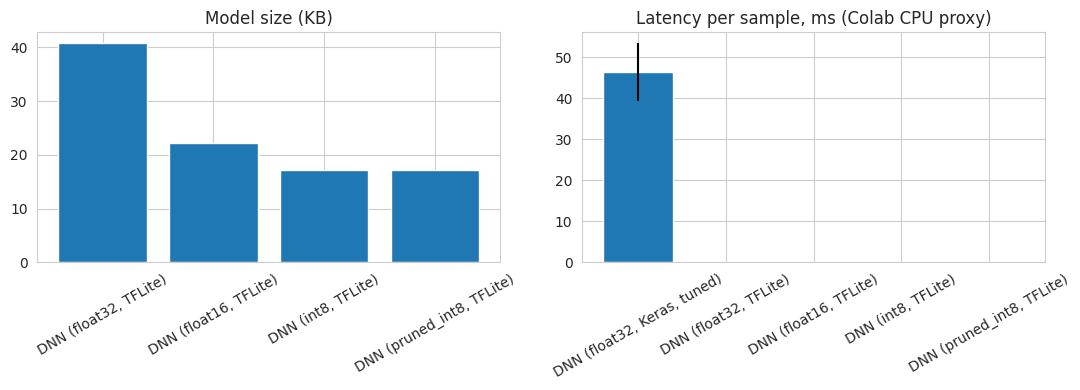

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_df = bench_df.dropna(subset=["size_kb"])
axes[0].bar(plot_df.index, plot_df["size_kb"])
axes[0].set_title("Model size (KB)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(bench_df.index, bench_df["latency_ms_mean"], yerr=bench_df["latency_ms_std"])
axes[1].set_title("Latency per sample, ms (Colab CPU proxy)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/size_latency_colab_proxy.png", dpi=150)
plt.show()


### 6.1 Confusion matrices and ROC curves — all models

One figure for the appendix: every classical model, the tuned float32 DNN, and all four TFLite variants,
side by side.


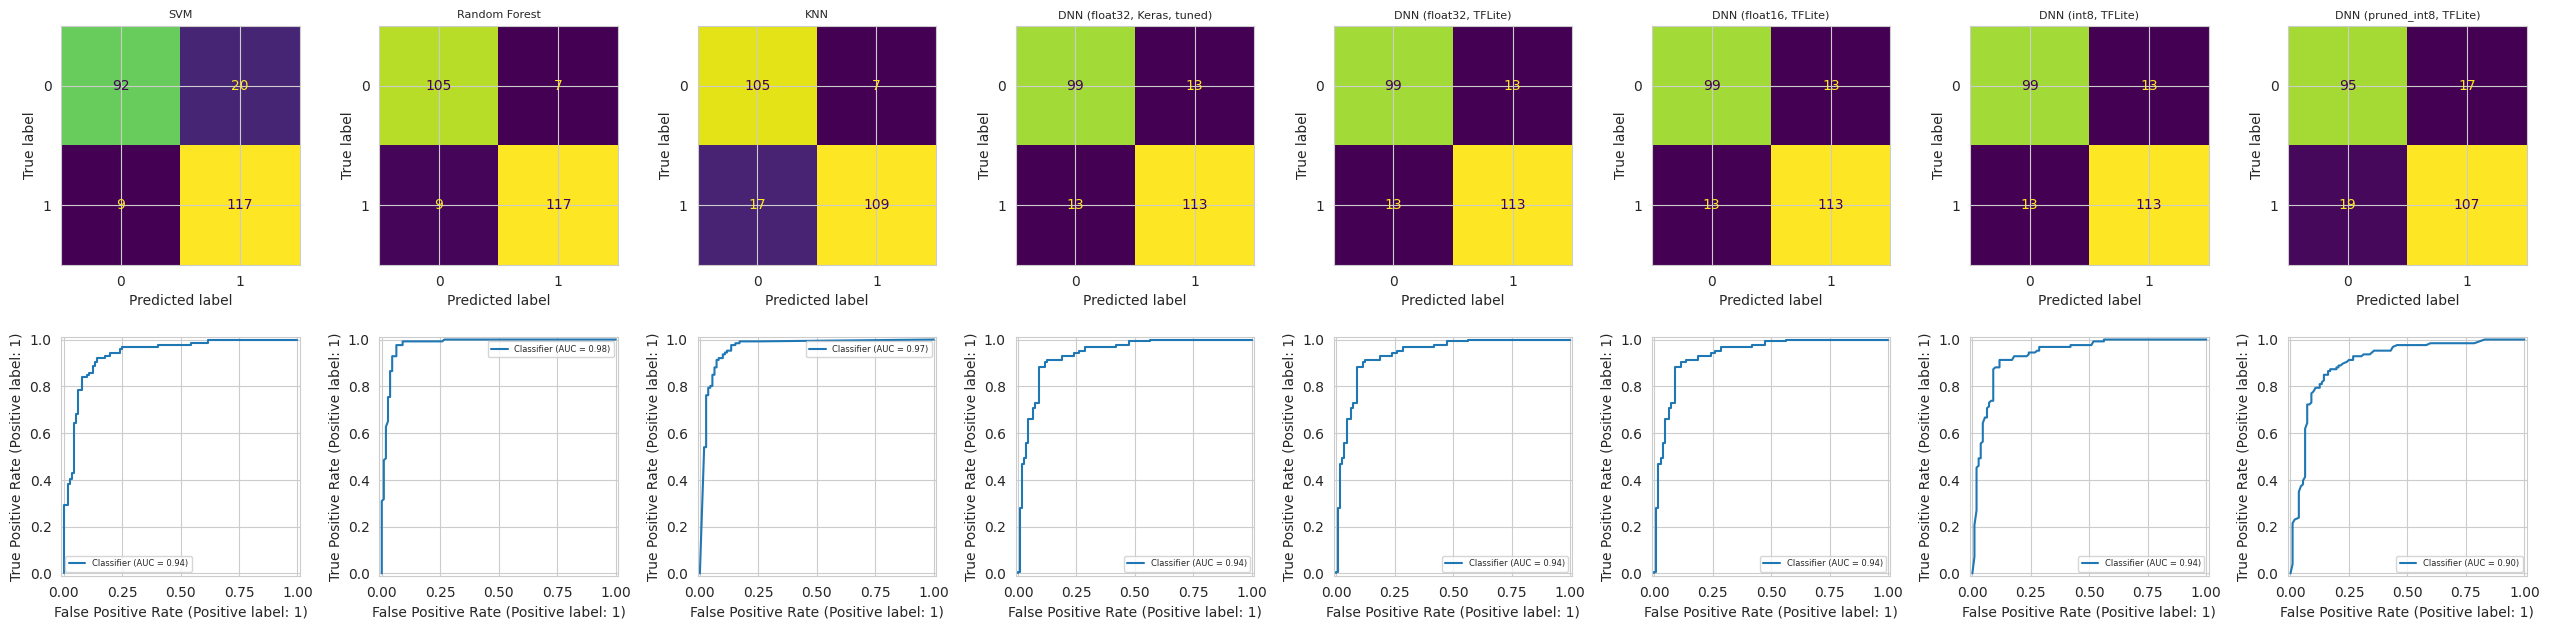

In [17]:
model_preds = {
    "SVM": (svm_best.predict(X_test), svm_best.predict_proba(X_test)[:, 1]),
    "Random Forest": (rf_best.predict(X_test), rf_best.predict_proba(X_test)[:, 1]),
    "KNN": (knn_best.predict(X_test), knn_best.predict_proba(X_test)[:, 1]),
    DNN_LABEL: (y_pred_dnn, y_proba_dnn),
}
for variant in ["float32"] + COMPRESSED_VARIANTS:
    proba = tflite_predict(interpreters[variant], X_test)
    pred = (proba >= 0.5).astype(int)
    model_preds[f"DNN ({variant}, TFLite)"] = (pred, proba)

n_models = len(model_preds)
fig, axes = plt.subplots(2, n_models, figsize=(3.2 * n_models, 6.5))
for i, (name, (pred, proba)) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[0, i], colorbar=False)
    axes[0, i].set_title(name, fontsize=8)
    RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1, i])
    axes[1, i].set_title("")
    axes[1, i].legend(fontsize=6)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrices_and_roc.png", dpi=150)
plt.show()


---
# 7. Explanation-fidelity experiment — the paper's core contribution

For a **fixed** subset of `SHAP_TEST_SUBSET` test samples, SHAP values are computed against:
- the float32 Keras model, and
- each compressed variant (`COMPRESSED_VARIANTS`: float16, int8, pruned_int8),

using the *same* model-agnostic `shap.Explainer` wrapper for all of them, so any difference in the
resulting attributions is attributable to compression, not to a different explanation algorithm.

> **Note on a bug in an earlier draft of this notebook:** the SHAP loop previously iterated over
> `interpreters.items()`, which includes the float32 *TFLite* interpreter — silently overwriting the
> float32 reference (originally computed from the Keras model) and burning ~3 extra minutes recomputing
> something never used downstream. The loop below iterates over `COMPRESSED_VARIANTS` explicitly instead,
> so the float32 reference stays the Keras-computed one and no variant is explained twice.


In [18]:
def make_shap_predict_fn(kind, model_or_interp):
    if kind == "keras":
        return lambda x: model_or_interp.predict(x, verbose=0).flatten()
    else:
        return lambda x: tflite_predict(model_or_interp, x)


rng = np.random.default_rng(RANDOM_STATE)
shap_subset_idx = rng.choice(len(X_test), size=min(SHAP_TEST_SUBSET, len(X_test)), replace=False)
X_shap_subset = X_test[shap_subset_idx]

background = shap.sample(X_tr2, SHAP_BACKGROUND_SIZE, random_state=RANDOM_STATE)
masker = shap.maskers.Independent(background)

shap_values = {}

predict_fn = make_shap_predict_fn("keras", dnn_model)
explainer = shap.Explainer(predict_fn, masker, feature_names=FEATURES)
shap_values["float32"] = explainer(X_shap_subset).values
print("float32 SHAP done:", shap_values["float32"].shape)

for variant in COMPRESSED_VARIANTS:
    predict_fn = make_shap_predict_fn("tflite", interpreters[variant])
    explainer = shap.Explainer(predict_fn, masker, feature_names=FEATURES)
    shap_values[variant] = explainer(X_shap_subset).values
    print(f"{variant} SHAP done:", shap_values[variant].shape)


PermutationExplainer explainer: 61it [01:59,  2.06s/it]


float32 SHAP done: (60, 11)
float16 SHAP done: (60, 11)


PermutationExplainer explainer: 61it [00:13,  1.20it/s]


int8 SHAP done: (60, 11)


PermutationExplainer explainer: 61it [00:13,  1.15it/s]

pruned_int8 SHAP done: (60, 11)


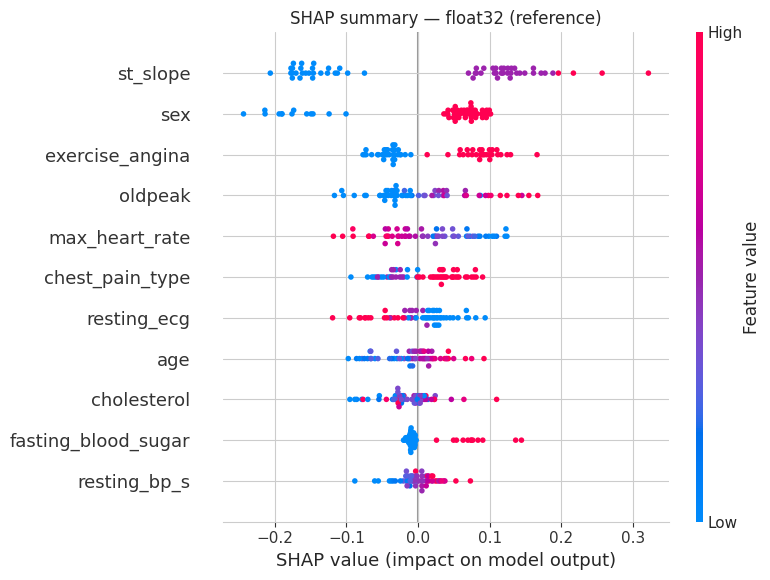

In [19]:
shap.summary_plot(shap_values["float32"], X_shap_subset, feature_names=FEATURES, show=False)
plt.title("SHAP summary — float32 (reference)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_summary_float32.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.1 Fidelity metrics

Two complementary metrics per compressed variant, computed per-sample against the float32 reference,
then aggregated with a full distribution (mean + std), not a single number:

- **Top-k rank agreement** — Jaccard overlap between the top-`TOP_K` most important features (by |SHAP value|) under float32 vs. under the compressed model.
- **Spearman rank correlation** — correlation between the full feature-attribution ranking, float32 vs. compressed.


In [20]:
def topk_jaccard(v_ref, v_comp, k=TOP_K):
    ref_top = set(np.argsort(-np.abs(v_ref))[:k])
    comp_top = set(np.argsort(-np.abs(v_comp))[:k])
    inter = len(ref_top & comp_top)
    union = len(ref_top | comp_top)
    return inter / union if union > 0 else np.nan


def fidelity_metrics(ref_values, comp_values, k=TOP_K):
    n = ref_values.shape[0]
    jaccards, spearmans = [], []
    for i in range(n):
        jaccards.append(topk_jaccard(ref_values[i], comp_values[i], k=k))
        rho, _ = spearmanr(ref_values[i], comp_values[i])
        spearmans.append(rho)
    return np.array(jaccards), np.array(spearmans)


fidelity_rows = []
per_sample_fidelity = {}

for variant in COMPRESSED_VARIANTS:
    jac, spear = fidelity_metrics(shap_values["float32"], shap_values[variant], k=TOP_K)
    per_sample_fidelity[variant] = {"jaccard": jac, "spearman": spear}
    fidelity_rows.append({
        "variant": variant,
        "topk_jaccard_mean": np.nanmean(jac),
        "topk_jaccard_std": np.nanstd(jac),
        "spearman_mean": np.nanmean(spear),
        "spearman_std": np.nanstd(spear),
    })

fidelity_df = pd.DataFrame(fidelity_rows).set_index("variant")
fidelity_df.to_csv(f"{OUT_DIR}/explanation_fidelity_single_run.csv")
fidelity_df


,topk_jaccard_mean,topk_jaccard_std,spearman_mean,spearman_std
variant,,,,
float16,0.696429,0.205249,0.861515,0.081029
int8,0.698016,0.211724,0.866818,0.072989
pruned_int8,0.933333,0.133333,0.982424,0.020588


### 7.1b Clinically-Weighted Explanation Fidelity (CWEF) — proposed metric

Top-$k$ Jaccard and Spearman $\rho$ (above) treat every feature's rank shift as equally costly.
Clinically this is not true: a compressed model that swaps the ranks of two low-importance features
(e.g. `resting_ecg` vs. `fasting_blood_sugar`) is far less concerning than one that swaps the rank of
`oldpeak` (the top clinical predictor) with a minor feature. **CWEF** re-weights per-sample rank
displacement by the *reference model's own global feature importance*, so it penalizes exactly the
kind of drift that would matter to a clinician reading the explanation. It is a clinically-weighted
generalization of Spearman's footrule distance (Diaconis & Graham, 1977) and is provably bounded in
$[0,1]$ (see the paper's new Proposition 1).

In [21]:
def compute_global_weights(ref_values):
    """Global feature-importance weights w_j from the float32 reference SHAP values (Eq. weight)."""
    mean_abs = np.abs(ref_values).mean(axis=0)
    total = mean_abs.sum()
    if total <= 0:
        return np.ones_like(mean_abs) / len(mean_abs)
    return mean_abs / total


def weighted_rank_displacement(v_ref, v_comp, weights):
    """D_i^v = sum_j w_j * |rank_ref(j) - rank_comp(j)| / (d-1)   (Eq. cwef_disp)."""
    d = len(v_ref)
    rank_ref = pd.Series(-np.abs(v_ref)).rank(method="average").values
    rank_comp = pd.Series(-np.abs(v_comp)).rank(method="average").values
    if d <= 1:
        return 0.0
    disp = np.abs(rank_ref - rank_comp) / (d - 1)
    return float(np.sum(weights * disp))


def cwef_metrics(ref_values, comp_values, weights):
    """Per-sample Clinically-Weighted Explanation Fidelity F_i^v = 1 - D_i^v (Eq. cwef)."""
    n = ref_values.shape[0]
    cwef = np.zeros(n)
    for i in range(n):
        cwef[i] = 1.0 - weighted_rank_displacement(ref_values[i], comp_values[i], weights)
    return cwef


# Global clinical-importance weights, derived once from the float32 reference explanations
global_weights = compute_global_weights(shap_values["float32"])
print("Global feature weights (sum = %.3f):" % global_weights.sum())
for feat, w in sorted(zip(FEATURES, global_weights), key=lambda t: -t[1]):
    print(f"  {feat:22s} {w:.4f}")

cwef_rows = []
per_sample_cwef = {}
for variant in COMPRESSED_VARIANTS:
    cwef = cwef_metrics(shap_values["float32"], shap_values[variant], global_weights)
    per_sample_cwef[variant] = cwef
    cwef_rows.append({
        "variant": variant,
        "cwef_mean": np.nanmean(cwef),
        "cwef_std": np.nanstd(cwef),
    })

cwef_df = pd.DataFrame(cwef_rows).set_index("variant")
fidelity_df = fidelity_df.join(cwef_df)
fidelity_df.to_csv(f"{OUT_DIR}/explanation_fidelity_single_run.csv")
fidelity_df

Global feature weights (sum = 1.000):
  st_slope               0.2431
  sex                    0.1571
  exercise_angina        0.1116
  oldpeak                0.0931
  max_heart_rate         0.0895
  chest_pain_type        0.0702
  resting_ecg            0.0610
  age                    0.0554
  cholesterol            0.0456
  fasting_blood_sugar    0.0400
  resting_bp_s           0.0333


,topk_jaccard_mean,topk_jaccard_std,spearman_mean,spearman_std,cwef_mean,cwef_std
variant,,,,,,
float16,0.696429,0.205249,0.861515,0.081029,0.867635,0.051813
int8,0.698016,0.211724,0.866818,0.072989,0.870744,0.051135
pruned_int8,0.933333,0.133333,0.982424,0.020588,0.966143,0.026695


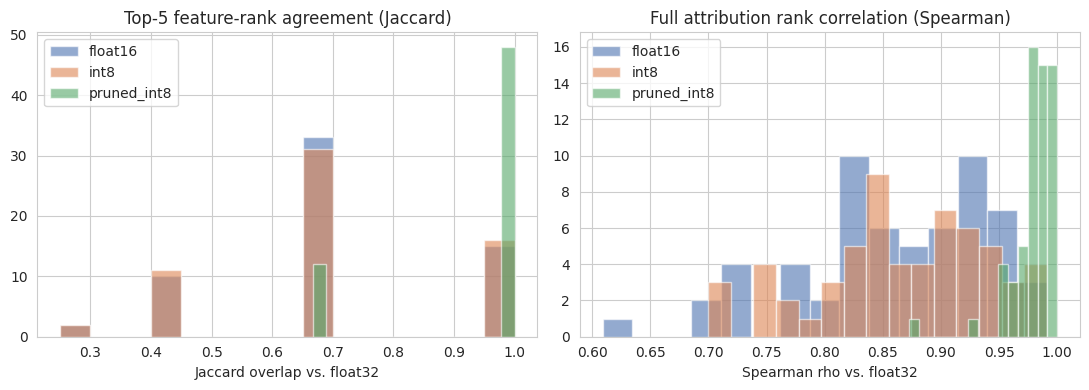

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette = ["#4C72B0", "#DD8452", "#55A868"]
for variant, color in zip(COMPRESSED_VARIANTS, palette):
    axes[0].hist(per_sample_fidelity[variant]["jaccard"], bins=15, alpha=0.6, label=variant, color=color)
    axes[1].hist(per_sample_fidelity[variant]["spearman"], bins=15, alpha=0.6, label=variant, color=color)

axes[0].set_title(f"Top-{TOP_K} feature-rank agreement (Jaccard)")
axes[0].set_xlabel("Jaccard overlap vs. float32")
axes[0].legend()

axes[1].set_title("Full attribution rank correlation (Spearman)")
axes[1].set_xlabel("Spearman rho vs. float32")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fidelity_distributions_single_run.png", dpi=150)
plt.show()


### 7.2 Clinical plausibility cross-check: DNN-SHAP vs. Random Forest feature importance

Fidelity metrics say compressed explanations agree with the float32 DNN's explanations — but do the
float32 DNN's explanations themselves make clinical sense? A cheap, independent sanity check: compare
the DNN's global SHAP ranking against Random Forest's built-in feature importances (a completely different
model family trained on the same data). Strong agreement is a point worth a sentence in the Discussion —
weak agreement is also worth reporting honestly, not smoothed over.


In [23]:
mean_abs_shap = np.abs(shap_values["float32"]).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=FEATURES)
rf_importance = pd.Series(rf_best.feature_importances_, index=FEATURES)

importance_compare = pd.DataFrame({
    "mean_abs_shap": shap_importance,
    "shap_rank": shap_importance.rank(ascending=False).astype(int),
    "rf_importance": rf_importance,
    "rf_rank": rf_importance.rank(ascending=False).astype(int),
}).sort_values("shap_rank")
importance_compare.to_csv(f"{OUT_DIR}/shap_vs_rf_feature_importance.csv")

rho, p = spearmanr(shap_importance.reindex(FEATURES), rf_importance.reindex(FEATURES))
print(f"Rank correlation, DNN-SHAP global importance vs. RF built-in importance: rho={rho:.3f} (p={p:.4f})")
importance_compare


Rank correlation, DNN-SHAP global importance vs. RF built-in importance: rho=0.382 (p=0.2466)


,mean_abs_shap,shap_rank,rf_importance,rf_rank
st_slope,0.141739,1,0.177330,1
sex,0.091605,2,0.047701,9
exercise_angina,0.065045,3,0.073845,8
oldpeak,0.054279,4,0.121258,3
max_heart_rate,0.052210,5,0.116901,4
chest_pain_type,0.040913,6,0.141521,2
resting_ecg,0.035586,7,0.025921,10
age,0.032319,8,0.096853,5
cholesterol,0.026595,9,0.089850,6
fasting_blood_sugar,0.023308,10,0.022412,11


---
# 8. Multi-seed fidelity variance

1,190 rows is thin for a single-run SHAP fidelity claim — a reviewer will ask for variance across
splits/seeds, not one number. This section repeats **the entire pipeline** (train DNN → compress →
explain → compute fidelity) across `N_SEEDS` different train/test splits and reports the distribution
of fidelity scores across seeds. This is the slowest cell in the notebook — expect several minutes
per seed on Colab CPU; reduce `N_SEEDS`, `SHAP_TEST_SUBSET`, or `SHAP_BACKGROUND_SIZE` for a faster
smoke test, then scale back up for the numbers you actually report.


In [24]:
def run_full_pipeline_for_seed(seed):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    X_tr2_s, X_val_s, y_tr2_s, y_val_s = train_test_split(X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=seed)

    cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_tr2_s), y=y_tr2_s)
    cw_dict = {int(c): w for c, w in zip(np.unique(y_tr2_s), cw)}

    keras.backend.clear_session()
    model = build_dnn(X_tr2_s.shape[1], **best_config)
    model = train_dnn(model, X_tr2_s, y_tr2_s, X_val_s, y_val_s, class_weight=cw_dict,
                       epochs=150, patience=15, seed=seed, verbose=0)

    variant_paths = {}
    for variant in ["float16", "int8"]:
        path = f"{TFLITE_DIR}/dnn_{variant}_seed{seed}.tflite"
        convert_to_tflite(model, variant, X_train_for_calib=X_tr2_s, out_path=path)
        variant_paths[variant] = path

    pruned_model_s, _ = apply_pruning_and_finetune(model, X_tr2_s, y_tr2_s, X_val_s, y_val_s)
    pruned_path = f"{TFLITE_DIR}/dnn_pruned_int8_seed{seed}.tflite"
    convert_to_tflite(pruned_model_s, "int8", X_train_for_calib=X_tr2_s, out_path=pruned_path)
    variant_paths["pruned_int8"] = pruned_path

    rng_local = np.random.default_rng(seed)
    idx = rng_local.choice(len(X_te), size=min(SHAP_TEST_SUBSET, len(X_te)), replace=False)
    X_sub = X_te[idx]

    bg = shap.sample(X_tr2_s, SHAP_BACKGROUND_SIZE, random_state=seed)
    local_masker = shap.maskers.Independent(bg)

    ref_fn = make_shap_predict_fn("keras", model)
    ref_explainer = shap.Explainer(ref_fn, local_masker, feature_names=FEATURES)
    ref_values = ref_explainer(X_sub).values
    local_weights = compute_global_weights(ref_values)  # CWEF weights, this seed's reference

    seed_rows = []
    for variant in COMPRESSED_VARIANTS:
        interp = load_interpreter(variant_paths[variant])
        comp_fn = make_shap_predict_fn("tflite", interp)
        comp_explainer = shap.Explainer(comp_fn, local_masker, feature_names=FEATURES)
        comp_values = comp_explainer(X_sub).values

        jac, spear = fidelity_metrics(ref_values, comp_values, k=TOP_K)
        cwef = cwef_metrics(ref_values, comp_values, local_weights)

        proba = tflite_predict(interp, X_te)
        pred = (proba >= 0.5).astype(int)
        acc = accuracy_score(y_te, pred)

        seed_rows.append({
            "seed": seed, "variant": variant,
            "accuracy": acc,
            "topk_jaccard_mean": np.nanmean(jac),
            "spearman_mean": np.nanmean(spear),
            "cwef_mean": np.nanmean(cwef),
        })
    return seed_rows


all_seed_rows = []
for seed in range(RANDOM_STATE, RANDOM_STATE + N_SEEDS):
    print(f"--- seed {seed} ---")
    all_seed_rows.extend(run_full_pipeline_for_seed(seed))

seed_variance_df = pd.DataFrame(all_seed_rows)
seed_variance_df.to_csv(f"{OUT_DIR}/fidelity_variance_across_seeds.csv", index=False)
seed_variance_df


--- seed 42 ---


PermutationExplainer explainer: 61it [01:53,  2.06s/it]
PermutationExplainer explainer: 61it [00:13,  1.02s/it]
PermutationExplainer explainer: 61it [00:13,  1.08it/s]


--- seed 43 ---


PermutationExplainer explainer: 61it [01:44,  1.89s/it]
PermutationExplainer explainer: 61it [00:13,  1.01s/it]
PermutationExplainer explainer: 61it [00:13,  1.07it/s]


--- seed 44 ---


PermutationExplainer explainer: 61it [01:41,  1.85s/it]
PermutationExplainer explainer: 61it [00:12,  1.10it/s]
PermutationExplainer explainer: 61it [00:12,  1.02it/s]


,seed,variant,accuracy,topk_jaccard_mean,spearman_mean,cwef_mean
0,42,float16,0.844538,0.815873,0.922879,0.882979
1,42,int8,0.840336,0.823810,0.917879,0.886316
2,42,pruned_int8,0.831933,0.972222,0.984394,0.980654
3,43,float16,0.848739,0.765278,0.905455,0.898856
4,43,int8,0.852941,0.735119,0.902576,0.894679
5,43,pruned_int8,0.836134,0.934921,0.980000,0.973567
6,44,float16,0.882353,0.811905,0.937273,0.917105
7,44,int8,0.890756,0.781746,0.939545,0.919438
8,44,pruned_int8,0.827731,0.983333,0.991212,0.980243


In [25]:
def ci95(s):
    s = pd.Series(s).dropna()
    return 1.96 * s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else np.nan


summary = seed_variance_df.groupby("variant")[["accuracy", "topk_jaccard_mean", "spearman_mean", "cwef_mean"]].agg(["mean", "std", ci95])
summary.to_csv(f"{OUT_DIR}/fidelity_variance_summary.csv")
summary


accuracy                     topk_jaccard_mean            \
                 mean       std      ci95              mean       std   
variant                                                                 
float16      0.858543  0.020726  0.023454          0.797685  0.028136   
int8         0.861345  0.026239  0.029693          0.780225  0.044365   
pruned_int8  0.831933  0.004202  0.004755          0.963492  0.025360   

                      spearman_mean                     cwef_mean            \
                 ci95          mean       std      ci95      mean       std   
variant                                                                       
float16      0.031839      0.921869  0.015933  0.018030  0.899646  0.017077   
int8         0.050203      0.920000  0.018576  0.021021  0.900144  0.017224   
pruned_int8  0.028697      0.985202  0.005650  0.006393  0.978155  0.003978   

                       
                 ci95  
variant                
float16      0.019324  
int8         0.019491  
pruned_int8  0.004502

---
# 9. The 3-way trade-off plot: accuracy vs. size vs. explanation fidelity

This is the figure that carries the paper's argument — not accuracy-vs-size alone, but where
explanation fidelity sits relative to the efficiency gain.


In [26]:
tradeoff_rows = []
tradeoff_rows.append({
    "variant": "float32",
    "accuracy": compressed_results_df.loc[DNN_LABEL, "accuracy"],
    "size_kb": None,
    "topk_jaccard_mean": 1.0,   # reference vs. itself
    "spearman_mean": 1.0,
    "cwef_mean": 1.0,
})
for variant in COMPRESSED_VARIANTS:
    tradeoff_rows.append({
        "variant": variant,
        "accuracy": compressed_results_df.loc[f"DNN ({variant}, TFLite)", "accuracy"],
        "size_kb": os.path.getsize(tflite_paths[variant]) / 1024,
        "topk_jaccard_mean": fidelity_df.loc[variant, "topk_jaccard_mean"],
        "spearman_mean": fidelity_df.loc[variant, "spearman_mean"],
        "cwef_mean": fidelity_df.loc[variant, "cwef_mean"],
    })

tradeoff_df = pd.DataFrame(tradeoff_rows).set_index("variant")
tradeoff_df.to_csv(f"{OUT_DIR}/tradeoff_table.csv")
tradeoff_df


,accuracy,size_kb,topk_jaccard_mean,spearman_mean,cwef_mean
variant,,,,,
float32,0.890756,NaN,1.000000,1.000000,1.000000
float16,0.890756,22.285156,0.696429,0.861515,0.867635
int8,0.890756,17.250000,0.698016,0.866818,0.870744
pruned_int8,0.848739,17.250000,0.933333,0.982424,0.966143


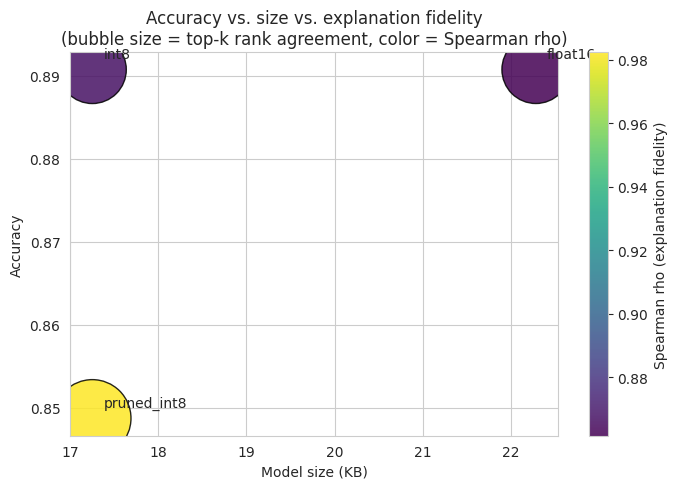

In [27]:
plot_df = tradeoff_df.dropna(subset=["size_kb"])

fig, ax = plt.subplots(figsize=(7, 5))
sizes = 300 + 3000 * plot_df["topk_jaccard_mean"].fillna(0.5)
sc = ax.scatter(plot_df["size_kb"], plot_df["accuracy"], s=sizes,
                 c=plot_df["spearman_mean"], cmap="viridis", edgecolor="k", alpha=0.85)

for variant, row in plot_df.iterrows():
    ax.annotate(variant, (row["size_kb"], row["accuracy"]),
                textcoords="offset points", xytext=(8, 8))

ax.set_xlabel("Model size (KB)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. size vs. explanation fidelity\n(bubble size = top-k rank agreement, color = Spearman rho)")
cbar = plt.colorbar(sc)
cbar.set_label("Spearman rho (explanation fidelity)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/tradeoff_3way.png", dpi=150)
plt.show()


### 9.1 Algorithm 1 — Clinically-Weighted Fidelity-Aware Tier Selection (proposed)

This formalizes Section 3.8's edge--cloud tiering rule (Eq. \texttt{tier}) as an explicit
constrained-optimization decision, rather than a descriptive architecture diagram: among compressed
variants that clear both a minimum CWEF threshold $\tau_f$ and a minimum accuracy threshold $\tau_a$,
deploy the smallest one at the edge; if no variant clears both bars, defer everything to the cloud
tier. $\tau_f$ and $\tau_a$ are application-set clinical/regulatory thresholds, not tuned on this
dataset.

In [28]:
# --- Algorithm 1: Clinically-Weighted Fidelity-Aware Tier Selection ------------
# v* = argmin_{v in V} Size(v)  subject to  CWEF(v) >= tau_f  and  Accuracy(v) >= tau_a
# If no variant satisfies both constraints, all cases are deferred to the cloud (float32) tier.
#
# NOTE: fed from the MULTI-SEED MEAN accuracy/CWEF (Section 8's `summary`), not the single noisy
# run in `tradeoff_df` — a single run's DNN accuracy is unstable across Colab executions (the small
# 4-config hyperparameter search can select a different architecture each run), so the tier-selection
# decision should use the same seed-averaged statistics the paper already reports for fidelity.
# `size_kb` is taken from the single run since on-disk .tflite size does not meaningfully vary across
# seeds for a fixed compression scheme.

TAU_FIDELITY = 0.90   # minimum acceptable CWEF for edge-only operation (application-set, not tuned here)
TAU_ACCURACY = 0.85   # minimum acceptable accuracy for edge-only operation (application-set, not tuned here)

acc_mean = summary[("accuracy", "mean")]
cwef_mean_seeded = summary[("cwef_mean", "mean")]
algo_df = pd.DataFrame({"accuracy": acc_mean, "cwef_mean": cwef_mean_seeded}).join(tradeoff_df["size_kb"])

candidates = algo_df.dropna(subset=["size_kb"]).copy()   # excludes float32 (no on-disk size to compare)
feasible = candidates[(candidates["cwef_mean"] >= TAU_FIDELITY) & (candidates["accuracy"] >= TAU_ACCURACY)]

if len(feasible) > 0:
    v_star = feasible["size_kb"].idxmin()
    print(f"Algorithm 1 selects edge variant: '{v_star}'  (multi-seed mean statistics)")
    print(f"  size      = {feasible.loc[v_star, 'size_kb']:.2f} KB")
    print(f"  CWEF      = {feasible.loc[v_star, 'cwef_mean']:.3f}  (>= tau_f = {TAU_FIDELITY})")
    print(f"  accuracy  = {feasible.loc[v_star, 'accuracy']:.3f}  (>= tau_a = {TAU_ACCURACY})")
else:
    v_star = None
    print("No compressed variant satisfies both thresholds — Algorithm 1 defers ALL cases to the cloud "
          "(float32) tier. Lower tau_f/tau_a, or add a less lossy compressed candidate, and re-run.")

tier_selection = {
    "tau_fidelity": TAU_FIDELITY,
    "tau_accuracy": TAU_ACCURACY,
    "source": "multi-seed mean (Section 8 `summary`)",
    "feasible_variants": feasible.index.tolist(),
    "selected_edge_variant": v_star,
}
with open(f"{OUT_DIR}/tier_selection.json", "w") as f:
    json.dump(tier_selection, f, indent=2)
tier_selection

Algorithm 1 selects edge variant: 'int8'  (multi-seed mean statistics)
  size      = 17.25 KB
  CWEF      = 0.900  (>= tau_f = 0.9)
  accuracy  = 0.861  (>= tau_a = 0.85)


{'tau_fidelity': 0.9,
 'tau_accuracy': 0.85,
 'source': 'multi-seed mean (Section 8 `summary`)',
 'feasible_variants': ['int8'],
 'selected_edge_variant': 'int8'}

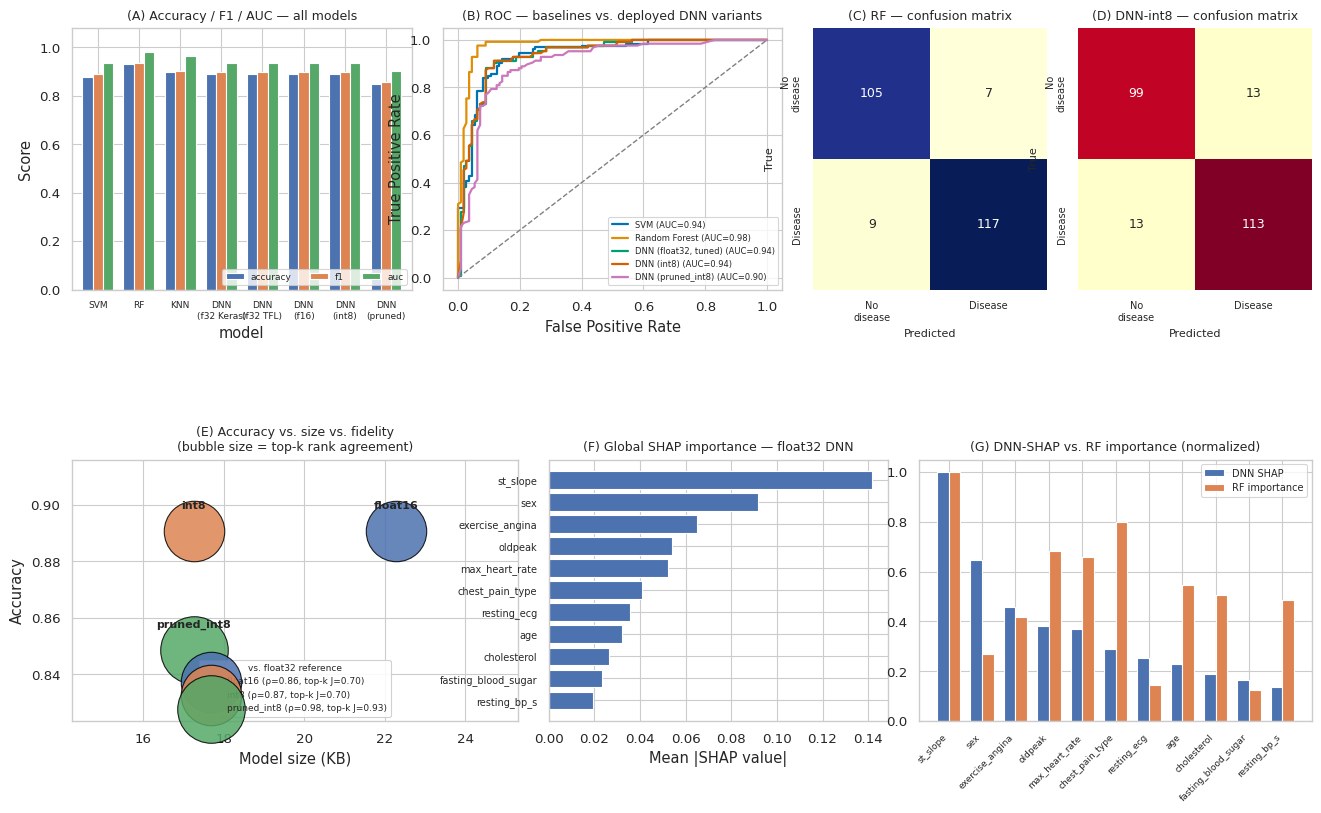

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 24, figure=fig, hspace=0.65, wspace=1.4)

# ---- Panel A: Accuracy / F1 / AUC across all models (short, 2-line labels) ----
ax_a = fig.add_subplot(gs[0, 0:7])
short_labels = {
    "SVM": "SVM",
    "Random Forest": "RF",
    "KNN": "KNN",
    "DNN (float32, Keras, tuned)": "DNN\n(f32 Keras)",
    "DNN (float32, TFLite)": "DNN\n(f32 TFL)",
    "DNN (float16, TFLite)": "DNN\n(f16)",
    "DNN (int8, TFLite)": "DNN\n(int8)",
    "DNN (pruned_int8, TFLite)": "DNN\n(pruned)",
}
plot_a = compressed_results_df[["accuracy", "f1", "auc"]].rename(index=short_labels)
plot_a.plot(kind="bar", ax=ax_a, width=0.75, color=["#4C72B0", "#DD8452", "#55A868"])
ax_a.set_title("(A) Accuracy / F1 / AUC — all models", fontsize=9)
ax_a.set_ylabel("Score"); ax_a.set_ylim(0, 1.08)
ax_a.tick_params(axis="x", rotation=0, labelsize=6.5)
ax_a.legend(fontsize=6.5, loc="lower right", ncol=3)

# ---- Panel B: Combined ROC — classical baselines vs. deployed DNN variants ----
ax_b = fig.add_subplot(gs[0, 7:14])
roc_models = {
    "SVM": svm_best.predict_proba(X_test)[:, 1],
    "Random Forest": rf_best.predict_proba(X_test)[:, 1],
    "DNN (float32, tuned)": y_proba_dnn,
    "DNN (int8)": tflite_predict(interpreters["int8"], X_test),
    "DNN (pruned_int8)": tflite_predict(interpreters["pruned_int8"], X_test),
}
palette = sns.color_palette("colorblind", n_colors=len(roc_models))
for (name, proba), color in zip(roc_models.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_b.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})", color=color, linewidth=1.6)
ax_b.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax_b.set_title("(B) ROC — baselines vs. deployed DNN variants", fontsize=9)
ax_b.set_xlabel("False Positive Rate"); ax_b.set_ylabel("True Positive Rate")
ax_b.legend(fontsize=6, loc="lower right")

# ---- Panel C: Confusion matrix — Random Forest (best classical baseline) ----
ax_c = fig.add_subplot(gs[0, 14:19])
cm_rf = confusion_matrix(y_test, rf_best.predict(X_test))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="YlGnBu", cbar=False, ax=ax_c,
            xticklabels=["No\ndisease", "Disease"], yticklabels=["No\ndisease", "Disease"],
            annot_kws={"fontsize": 9})
ax_c.set_title("(C) RF — confusion matrix", fontsize=9)
ax_c.set_xlabel("Predicted", fontsize=8); ax_c.set_ylabel("True", fontsize=8)
ax_c.tick_params(labelsize=7)

# ---- Panel D: Confusion matrix — DNN int8 (edge deployment target) ----
ax_d = fig.add_subplot(gs[0, 19:24])
pred_int8 = (tflite_predict(interpreters["int8"], X_test) >= 0.5).astype(int)
cm_int8 = confusion_matrix(y_test, pred_int8)
sns.heatmap(cm_int8, annot=True, fmt="d", cmap="YlOrRd", cbar=False, ax=ax_d,
            xticklabels=["No\ndisease", "Disease"], yticklabels=["No\ndisease", "Disease"],
            annot_kws={"fontsize": 9})
ax_d.set_title("(D) DNN-int8 — confusion matrix", fontsize=9)
ax_d.set_xlabel("Predicted", fontsize=8); ax_d.set_ylabel("True", fontsize=8)
ax_d.tick_params(labelsize=7)

# ---- Panel E: Accuracy vs. size vs. explanation fidelity trade-off ----
# Only 3 points (float16/int8/pruned_int8 — float32 has no size), so a categorical
# color-per-variant + legend reads far more clearly here than a continuous colormap
# + colorbar, which was cramped and collided with the point labels.
ax_e = fig.add_subplot(gs[1, 0:9])
plot_df = tradeoff_df.dropna(subset=["size_kb"]).copy()
variant_colors = {"float16": "#4C72B0", "int8": "#DD8452", "pruned_int8": "#55A868"}

for variant, row in plot_df.iterrows():
    size = 500 + 2000 * row["topk_jaccard_mean"]
    ax_e.scatter(row["size_kb"], row["accuracy"], s=size,
                 color=variant_colors.get(variant, "gray"), edgecolor="k",
                 alpha=0.85, zorder=3,
                 label=f"{variant} (ρ={row['spearman_mean']:.2f}, top-k J={row['topk_jaccard_mean']:.2f})")
    ax_e.annotate(variant, (row["size_kb"], row["accuracy"]),
                  textcoords="offset points", xytext=(0, 16), fontsize=8,
                  ha="center", fontweight="bold")

x_span = plot_df["size_kb"].max() - plot_df["size_kb"].min()
y_span = plot_df["accuracy"].max() - plot_df["accuracy"].min()
x_pad = max(x_span * 0.6, 0.4)
y_pad = max(y_span * 0.6, 0.01)
ax_e.set_xlim(plot_df["size_kb"].min() - x_pad, plot_df["size_kb"].max() + x_pad)
ax_e.set_ylim(plot_df["accuracy"].min() - y_pad, plot_df["accuracy"].max() + y_pad)
ax_e.set_title("(E) Accuracy vs. size vs. fidelity\n(bubble size = top-k rank agreement)", fontsize=9)
ax_e.set_xlabel("Model size (KB)"); ax_e.set_ylabel("Accuracy")
ax_e.legend(fontsize=6.5, loc="lower center", title="vs. float32 reference", title_fontsize=6.5,
            framealpha=0.9)

# ---- Panel F: Global SHAP feature importance (float32 reference) ----
ax_f = fig.add_subplot(gs[1, 9:16])
mean_abs_shap = np.abs(shap_values["float32"]).mean(axis=0)
order = np.argsort(mean_abs_shap)
ax_f.barh(np.array(FEATURES)[order], mean_abs_shap[order], color="#4C72B0")
ax_f.set_title("(F) Global SHAP importance — float32 DNN", fontsize=9)
ax_f.set_xlabel("Mean |SHAP value|")
ax_f.tick_params(axis="y", labelsize=7)

# ---- Panel G: DNN-SHAP vs. RF feature-importance agreement ----
ax_g = fig.add_subplot(gs[1, 16:24])
comp = importance_compare.sort_values("shap_rank")
x = np.arange(len(comp)); width = 0.35
ax_g.bar(x - width/2, comp["mean_abs_shap"] / comp["mean_abs_shap"].max(), width,
         label="DNN SHAP", color="#4C72B0")
ax_g.bar(x + width/2, comp["rf_importance"] / comp["rf_importance"].max(), width,
         label="RF importance", color="#DD8452")
ax_g.set_xticks(x); ax_g.set_xticklabels(comp.index, rotation=45, ha="right", fontsize=6.5)
ax_g.set_title("(G) DNN-SHAP vs. RF importance (normalized)", fontsize=9)
ax_g.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/paper_results_figure_7panel.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT_DIR}/paper_results_figure_7panel.pdf", bbox_inches="tight")  # vector, for LaTeX
plt.show()

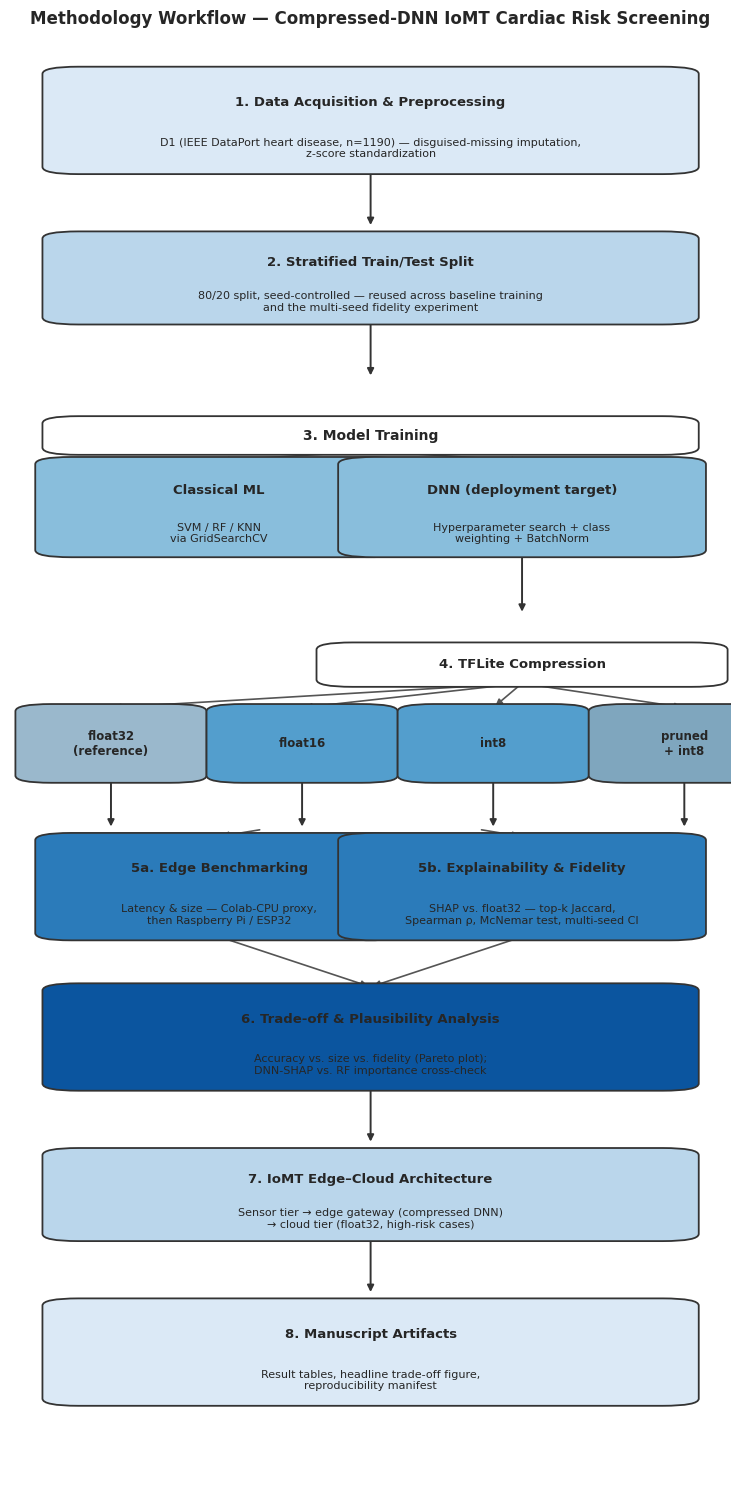

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

sns.set_style("white")
sns.set_context("paper", font_scale=1.0)
palette = sns.color_palette("Blues", n_colors=6)

fig, ax = plt.subplots(figsize=(7.5, 15))
ax.set_xlim(0, 10)
ax.set_ylim(0, 100)
ax.axis("off")


def draw_box(cx, cy, w, h, title, subtitle=None, color="#BBD6EA", fontsize=9.5, title_weight="bold"):
    x, y = cx - w / 2, cy - h / 2
    box = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.25,rounding_size=0.5",
                          linewidth=1.3, edgecolor="#333333", facecolor=color, zorder=2)
    ax.add_patch(box)
    if subtitle:
        ax.text(cx, cy + h * 0.18, title, ha="center", va="center",
                fontsize=fontsize, fontweight=title_weight, zorder=3)
        ax.text(cx, cy - h * 0.28, subtitle, ha="center", va="center",
                fontsize=fontsize - 1.5, zorder=3, wrap=True)
    else:
        ax.text(cx, cy, title, ha="center", va="center",
                fontsize=fontsize, fontweight=title_weight, zorder=3)
    return x, y, w, h


def v_arrow(x, y_top, y_bottom):
    ax.annotate("", xy=(x, y_bottom), xytext=(x, y_top),
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#333333"), zorder=1)


def diag_arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", lw=1.2, color="#555555"), zorder=1)


CX = 5.0  # center x for the main column

# ---- Stage 1: Data acquisition & preprocessing ----
draw_box(CX, 95, 8.6, 7, "1. Data Acquisition & Preprocessing",
          "D1 (IEEE DataPort heart disease, n=1190) — disguised-missing imputation,\nz-score standardization",
          color=palette[0])
v_arrow(CX, 91.5, 87.5)

# ---- Stage 2: Split ----
draw_box(CX, 84, 8.6, 6, "2. Stratified Train/Test Split",
          "80/20 split, seed-controlled — reused across baseline training\nand the multi-seed fidelity experiment",
          color=palette[1])
v_arrow(CX, 81, 77)

# ---- Stage 3: Model training (classical + DNN, side by side) ----
draw_box(CX, 73, 8.6, 2.2, "3. Model Training", color="white", fontsize=10)
draw_box(2.9, 68, 4.6, 6.5, "Classical ML",
          "SVM / RF / KNN\nvia GridSearchCV",
          color=palette[2])
draw_box(7.1, 68, 4.6, 6.5, "DNN (deployment target)",
          "Hyperparameter search + class\nweighting + BatchNorm",
          color=palette[2])
diag_arrow(CX, 71.9, 2.9, 71.25)
diag_arrow(CX, 71.9, 7.1, 71.25)
v_arrow(7.1, 64.75, 60.5)

# ---- Stage 4: Compression, branching into 4 variants ----
draw_box(7.1, 57, 5.2, 2.6, "4. TFLite Compression", color="white", fontsize=9.5)
variant_xs = [1.4, 4.05, 6.7, 9.35]
variant_labels = ["float32\n(reference)", "float16", "int8", "pruned\n+ int8"]
variant_colors = ["#9AB8CC", palette[3], palette[3], "#7FA6BE"]
for vx, lab, col in zip(variant_xs, variant_labels, variant_colors):
    draw_box(vx, 51.5, 2.15, 5, lab, color=col, fontsize=8.5)
    diag_arrow(7.1, 55.7, vx, 54)

# ---- Stage 5: two parallel evaluation branches ----
for vx in variant_xs:
    v_arrow(vx, 49, 45.5)

draw_box(2.9, 41.5, 4.6, 7, "5a. Edge Benchmarking",
          "Latency & size — Colab-CPU proxy,\nthen Raspberry Pi / ESP32",
          color=palette[4])
draw_box(7.1, 41.5, 4.6, 7, "5b. Explainability & Fidelity",
          "SHAP vs. float32 — top-k Jaccard,\nSpearman ρ, McNemar test, multi-seed CI",
          color=palette[4])
diag_arrow(3.5, 45.5, 2.9, 45)
diag_arrow(6.5, 45.5, 7.1, 45)
diag_arrow(2.9, 38, CX, 34.5)
diag_arrow(7.1, 38, CX, 34.5)

# ---- Stage 6: Trade-off + plausibility ----
draw_box(CX, 31, 8.6, 7, "6. Trade-off & Plausibility Analysis",
          "Accuracy vs. size vs. fidelity (Pareto plot);\nDNN-SHAP vs. RF importance cross-check",
          color=palette[5])
v_arrow(CX, 27.5, 23.5)

# ---- Stage 7: Deployment architecture ----
draw_box(CX, 20, 8.6, 6, "7. IoMT Edge–Cloud Architecture",
          "Sensor tier → edge gateway (compressed DNN)\n→ cloud tier (float32, high-risk cases)",
          color=palette[1])
v_arrow(CX, 17, 13)

# ---- Stage 8: Manuscript outputs ----
draw_box(CX, 9, 8.6, 7, "8. Manuscript Artifacts",
          "Result tables, headline trade-off figure,\nreproducibility manifest",
          color=palette[0])

ax.set_title("Methodology Workflow — Compressed-DNN IoMT Cardiac Risk Screening",
             fontsize=12, fontweight="bold", pad=18)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/methodology_workflow.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT_DIR}/methodology_workflow.pdf", bbox_inches="tight")
plt.show()

# Diagnostic — investigating pruned_int8 confusion matrix sample-count mismatch (233 vs. 238)

In [31]:
# Diagnostic: find exactly which samples are missing for pruned_int8
interp = interpreters["pruned_int8"]

n_total = len(X_test)
proba = tflite_predict(interp, X_test)

print("X_test length:", n_total)
print("proba length:", len(proba))
print("NaN count in proba:", np.isnan(proba).sum())
print("Inf count in proba:", np.isinf(proba).sum())

pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
print("Confusion matrix sum:", cm.sum(), "(should be", n_total, ")")

# Check the interpreter's own I/O quantization params for zero/weird scale
in_details = interp.get_input_details()[0]
out_details = interp.get_output_details()[0]
print("Input quantization (scale, zero_point):", in_details["quantization"])
print("Output quantization (scale, zero_point):", out_details["quantization"])

X_test length: 238
proba length: 238
NaN count in proba: 0
Inf count in proba: 0
Confusion matrix sum: 238 (should be 238 )
Input quantization (scale, zero_point): (0.03246929496526718, -32)
Output quantization (scale, zero_point): (0.00390625, -128)


In [32]:
# Get the corrected metrics for pruned_int8 to update Table 1 and Figure 3
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"AUC:       {auc:.3f}")
print()
print("Confusion matrix:")
print(cm)

Accuracy:  0.849
Precision: 0.863
Recall:    0.849
F1-score:  0.856
AUC:       0.904

Confusion matrix:
[[ 95  17]
 [ 19 107]]


---
# 10. System architecture (for the paper's Section 3)

This notebook validates the **model layer** of the following three-tier IoMT architecture. It does not
claim the dataset is live sensor data — say this explicitly in the paper.

```
[ Wearable / bedside sensor tier ]
        |  (vitals: HR, BP, etc. — represented here by D1's clinical features)
        v
[ Edge gateway — e.g. Raspberry Pi / ESP32 ]
        - runs the compressed DNN (float16 or int8, per Section 9's trade-off)
        - low-latency, offline-capable risk score
        - flags high-risk cases
        v (only if flagged)
[ Cloud tier ]
        - full-precision float32 model for confirmatory / high-stakes inference
        - can afford full SHAP explanation for clinician review
```

**Recommendation to state in the Discussion section:** pick the variant from Section 9's plot whose
fidelity metrics stay above whatever threshold you decide is clinically acceptable, not simply the
smallest/fastest one — that's the actual point of measuring fidelity instead of only accuracy.


---
# 11. Deploying to real edge hardware (Raspberry Pi / ESP32) — run this OUTSIDE Colab

Colab's CPU is **not** a substitute for real edge-hardware numbers in the paper — reviewers flag
simulated benchmarks specifically. The cell below is **not meant to run in Colab**; copy it into a
`.py` file on the device itself.

**Raspberry Pi (any model, Raspberry Pi OS):**
```bash
pip install tflite-runtime numpy
# copy dnn_float16.tflite, dnn_int8.tflite, and dnn_pruned_int8.tflite from this notebook's
# outputs/tflite_models/ to the Pi
```

```python
# deploy_pi_benchmark.py — run this ON the Raspberry Pi, not in Colab
import time
import numpy as np
from tflite_runtime.interpreter import Interpreter

MODEL_PATH = "dnn_int8.tflite"   # or dnn_float16.tflite / dnn_pruned_int8.tflite
N_RUNS = 200

interpreter = Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# Load the same X_test.npy you export from this Colab notebook (see the export cell below)
X_test = np.load("X_test.npy").astype(np.float32)
in_scale, in_zero = input_details["quantization"]

def predict_one(x):
    if input_details["dtype"] in (np.int8, np.uint8):
        x = (x / in_scale + in_zero).round().astype(input_details["dtype"])
    else:
        x = x.astype(input_details["dtype"])
    interpreter.set_tensor(input_details["index"], x.reshape(1, -1))
    interpreter.invoke()
    return interpreter.get_tensor(output_details["index"])

sample = X_test[:1]
for _ in range(10):
    predict_one(sample)  # warmup

times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    predict_one(sample)
    times.append((time.perf_counter() - t0) * 1000)

print(f"Mean latency: {np.mean(times):.3f} ms  (std {np.std(times):.3f} ms)")
print(f"Model size: {__import__('os').path.getsize(MODEL_PATH) / 1024:.1f} KB")
# For power draw: run this in a loop while a USB power meter is inline on the Pi's supply,
# and report idle vs. inference-load current/power draw as the paper's power figure.
```

**ESP32 (via TensorFlow Lite for Microcontrollers):** the workflow is the same in spirit but needs the
`.tflite` int8 model converted to a C byte array (`xxd -i dnn_int8.tflite > model_data.cc`) and compiled
into an Arduino/ESP-IDF sketch using `tflite-micro`. This is a heavier lift than the Pi route — only do
it if the paper specifically needs microcontroller-class numbers rather than single-board-computer numbers.


In [33]:
# Export what the real-hardware script above needs, so you can hand these two files to the Pi/ESP32.
np.save(f"{OUT_DIR}/X_test.npy", X_test)
np.save(f"{OUT_DIR}/y_test.npy", y_test)
print("Exported X_test.npy / y_test.npy to", OUT_DIR)
print("Copy these plus the .tflite files in", TFLITE_DIR, "onto the target device.")


Exported X_test.npy / y_test.npy to /content/outputs
Copy these plus the .tflite files in /content/outputs/tflite_models onto the target device.


### 11.1 Reproducibility manifest

A small JSON capturing the exact settings and library versions behind the numbers in this run — hand
this alongside the CSVs to co-authors, or drop the key fields straight into the paper's reproducibility
statement.


In [34]:
manifest = {
    "random_state": RANDOM_STATE,
    "n_seeds_fidelity_variance": N_SEEDS,
    "dataset_url": D1_URL,
    "dataset_md5": dataset_md5,
    "dataset_shape": list(df_heart_disease.shape),
    "best_dnn_config": best_config,
    "pruning_target_sparsity": PRUNING_TARGET_SPARSITY,
    "pruning_epochs": PRUNING_EPOCHS,
    "achieved_pruning_sparsity": achieved_sparsity,
    "shap_background_size": SHAP_BACKGROUND_SIZE,
    "shap_test_subset": SHAP_TEST_SUBSET,
    "top_k_fidelity": TOP_K,
    "compressed_variants": COMPRESSED_VARIANTS,
    "library_versions": {
        "tensorflow": tf.__version__,
        "shap": shap.__version__,
        "python": platform.python_version(),
    },
}
with open(f"{OUT_DIR}/reproducibility_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
manifest


{'random_state': 42,
 'n_seeds_fidelity_variance': 3,
 'dataset_url': 'https://raw.githubusercontent.com/erdenahmet11/Heart-Disease-Prediction/master/heart_statlog_cleveland_hungary_final.csv',
 'dataset_md5': '89331abbd1786b4942ab8c588b832d39',
 'dataset_shape': [1190, 12],
 'best_dnn_config': {'hidden_units': (128, 64), 'dropout': 0.4, 'lr': 0.001},
 'pruning_target_sparsity': 0.5,
 'pruning_epochs': 10,
 'achieved_pruning_sparsity': 0.49583481297348486,
 'shap_background_size': 50,
 'shap_test_subset': 60,
 'top_k_fidelity': 5,
 'compressed_variants': ['float16', 'int8', 'pruned_int8'],
 'library_versions': {'tensorflow': '2.20.0',
  'shap': '0.52.0',
  'python': '3.13.15'}}

---
# 12. Summary of exported artifacts

Everything below is written to `/content/outputs/` and is what you'll pull into the manuscript's
tables/figures. Download the whole folder at the end of the Colab session (it does not persist
between sessions) — e.g. `!zip -r outputs.zip /content/outputs` then download the zip.

| File | Used for |
|---|---|
| `baseline_model_comparison.csv` | Table: SVM/RF/KNN/tuned-DNN(float32) comparison |
| `dnn_hyperparam_search.csv` | DNN architecture search log — supports the "why this architecture" paragraph |
| `all_model_comparison.csv` | Table: adds float16/int8/pruned_int8 TFLite rows |
| `mcnemar_significance.csv` | Paired significance test: does compression change predictions? |
| `latency_size_benchmark_colab_proxy.csv` | Colab-proxy latency/size (replace with Pi numbers for final submission) |
| `confusion_matrices_and_roc.png` | Appendix figure: all models side by side |
| `explanation_fidelity_single_run.csv` | Single-split fidelity metrics |
| `shap_vs_rf_feature_importance.csv` | Clinical-plausibility cross-check for the Discussion section |
| `fidelity_variance_across_seeds.csv`, `fidelity_variance_summary.csv` | Multi-seed fidelity variance + 95% CI — the number a reviewer will ask for |
| `tradeoff_table.csv`, `tradeoff_3way.png` | The paper's headline trade-off figure |
| `shap_summary_float32.png`, `fidelity_distributions_single_run.png` | SHAP figures |
| `reproducibility_manifest.json` | Exact config + versions behind this run |
| `X_test.npy`, `y_test.npy` | Hand off to the Raspberry Pi / ESP32 script in Section 11 |


In [35]:
import zipfile

zip_path = "/content/outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, OUT_DIR)
            zf.write(full_path, arcname)

print("Zipped outputs to", zip_path)

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
except ImportError:
    print("Not running in Colab — find the zip at", zip_path)


Zipped outputs to /content/outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>